In [1]:
import warnings
warnings.filterwarnings('ignore')#ometimes things aren't broken enough to crash but something is worth flagging like using an outdated function

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r'C:\Users\sahil\Desktop\Bike Sharing Prediction\day.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\sahil\\Desktop\\Bike Sharing Prediction\\day.csv'

In [ ]:
df.rename(columns={'instant': 'SrNo', 'dteday': 'date','cnt':'count'}, inplace=True)

In [ ]:
df

,SrNo,date,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


In [ ]:
df.shape #how many rows and columns

(730, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SrNo        730 non-null    int64  
 1   date        730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  count       730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [ ]:
df.describe()

,SrNo,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [ ]:
#Assigning string values to season as it will misindicate the machine
#Only one weight w_season for all 4 seasons. The model cannot learn that spring and winter are both low but summer and fall are high. 
#astype treats it as category

In [ ]:
df.loc[(df['season'] == 1), 'season'] = 'spring'
df.loc[(df['season'] == 2), 'season'] = 'summer'
df.loc[(df['season'] == 3), 'season'] = 'fall'
df.loc[(df['season'] == 4), 'season'] = 'winter'

In [ ]:
df['yr'].astype('category').value_counts()

yr
0    365
1    365
Name: count, dtype: int64

In [ ]:
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

df['mnth'] = df['mnth'].map(month_map).astype('category')

In [ ]:
df['mnth'].astype('category').value_counts()

mnth
Aug    62
Dec    62
Jul    62
Jan    62
Oct    62
May    62
Mar    62
Apr    60
Nov    60
Jun    60
Sep    60
Feb    56
Name: count, dtype: int64

In [ ]:
weekday_map = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thur', 5:'Fri', 6:'Sat',0:'Sun'}
df['weekday'] = df['weekday'].map(weekday_map).astype('category')

In [ ]:
df['weekday'].astype('category').value_counts()

weekday
Mon     105
Sat     105
Sun     105
Fri     104
Thur    104
Tue     104
Wed     103
Name: count, dtype: int64

In [ ]:
weather_map = {1:'Clear', 2:'Mist', 3:'Light_Rain', 4:'Heavy_Rain'}
df['weathersit'] = df['weathersit'].map(weather_map).astype('category')

In [ ]:
df['weathersit'].astype('category').value_counts()

weathersit
Clear         463
Mist          246
Light_Rain     21
Name: count, dtype: int64

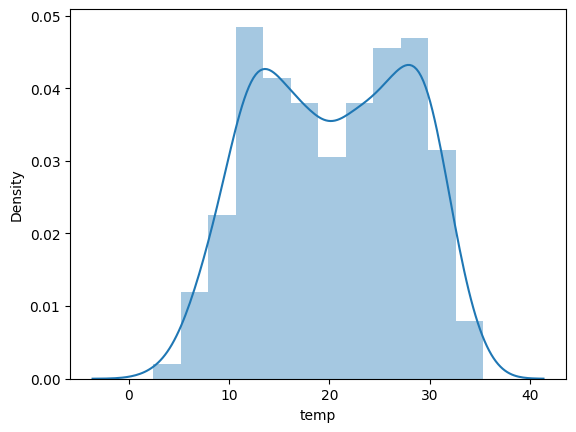

In [ ]:
# Temperature
sns.distplot(df['temp'])
plt.show()

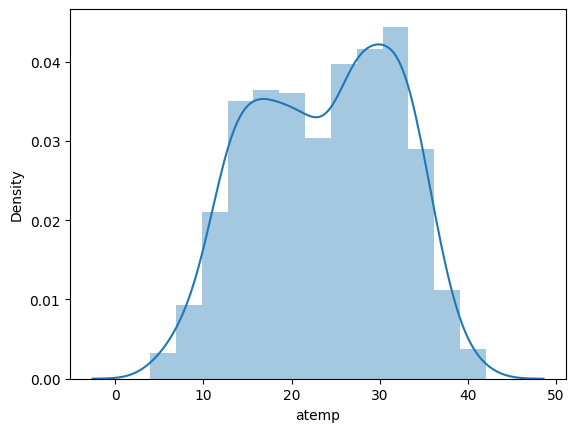

In [ ]:
# Actual Temperature
sns.distplot(df['atemp'])
plt.show()

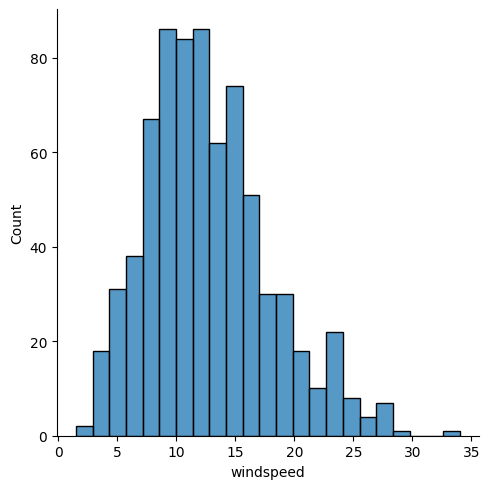

In [ ]:
#wind speed
sns.displot(df['windspeed'])
plt.show()

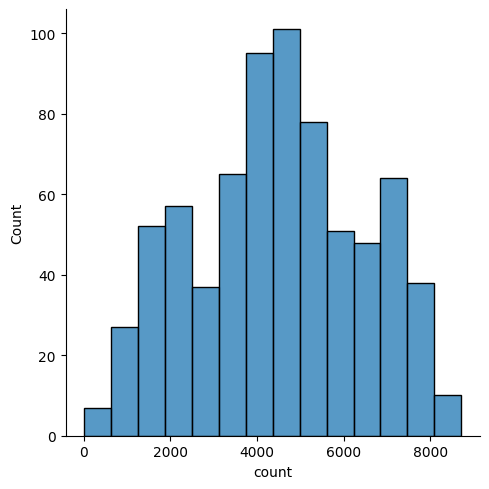

In [ ]:
#count
sns.displot(df['count'])
plt.show()

In [ ]:
#converting date to datetime format

In [ ]:
df['date'] = df['date'].astype('datetime64[ns]')

In [ ]:
dc=df.select_dtypes(exclude=['float64','datetime64[ns]','int64'])
dc.columns
dc

,season,mnth,weekday,weathersit
0,spring,Jan,Sat,Mist
1,spring,Jan,Sun,Mist
2,spring,Jan,Mon,Clear
3,spring,Jan,Tue,Clear
4,spring,Jan,Wed,Clear
...,...,...,...,...
725,spring,Dec,Thur,Mist
726,spring,Dec,Fri,Mist
727,spring,Dec,Sat,Mist
728,spring,Dec,Sun,Clear


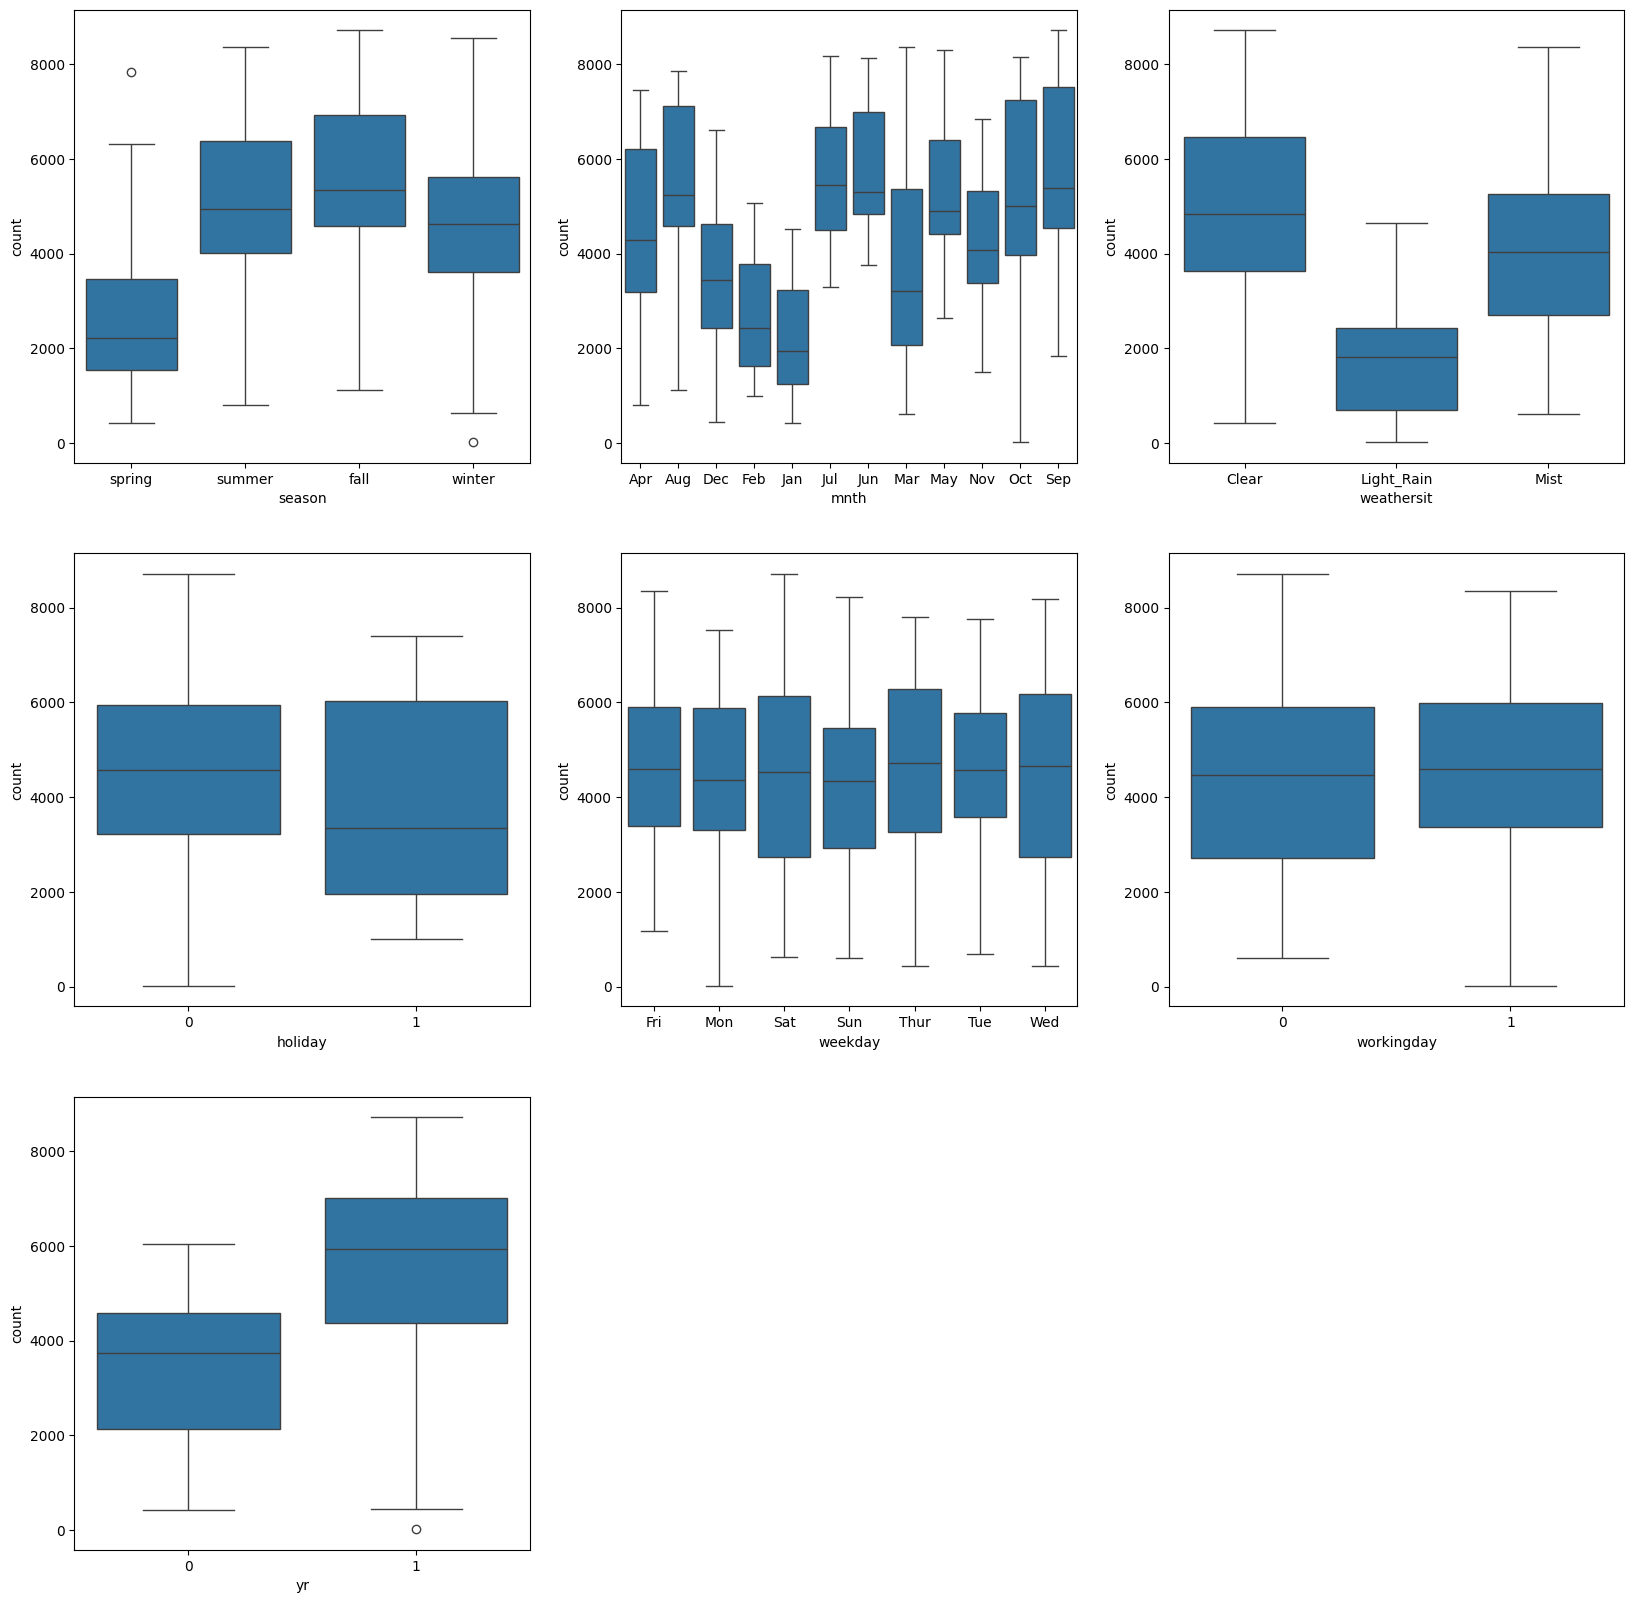

In [ ]:
plt.figure(figsize=(20,20))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'count', data=df)
plt.subplot(3,3,2)
sns.boxplot(x = 'mnth', y = 'count', data=df)
plt.subplot(3,3,3)
sns.boxplot(x = 'weathersit', y = 'count', data=df)
plt.subplot(3,3,4)
sns.boxplot(x = 'holiday', y = 'count', data=df)
plt.subplot(3,3,5)
sns.boxplot(x = 'weekday', y = 'count', data=df)
plt.subplot(3,3,6)
sns.boxplot(x = 'workingday', y = 'count', data=df)
plt.subplot(3,3,7)
sns.boxplot(x = 'yr', y = 'count', data=df)
plt.show()

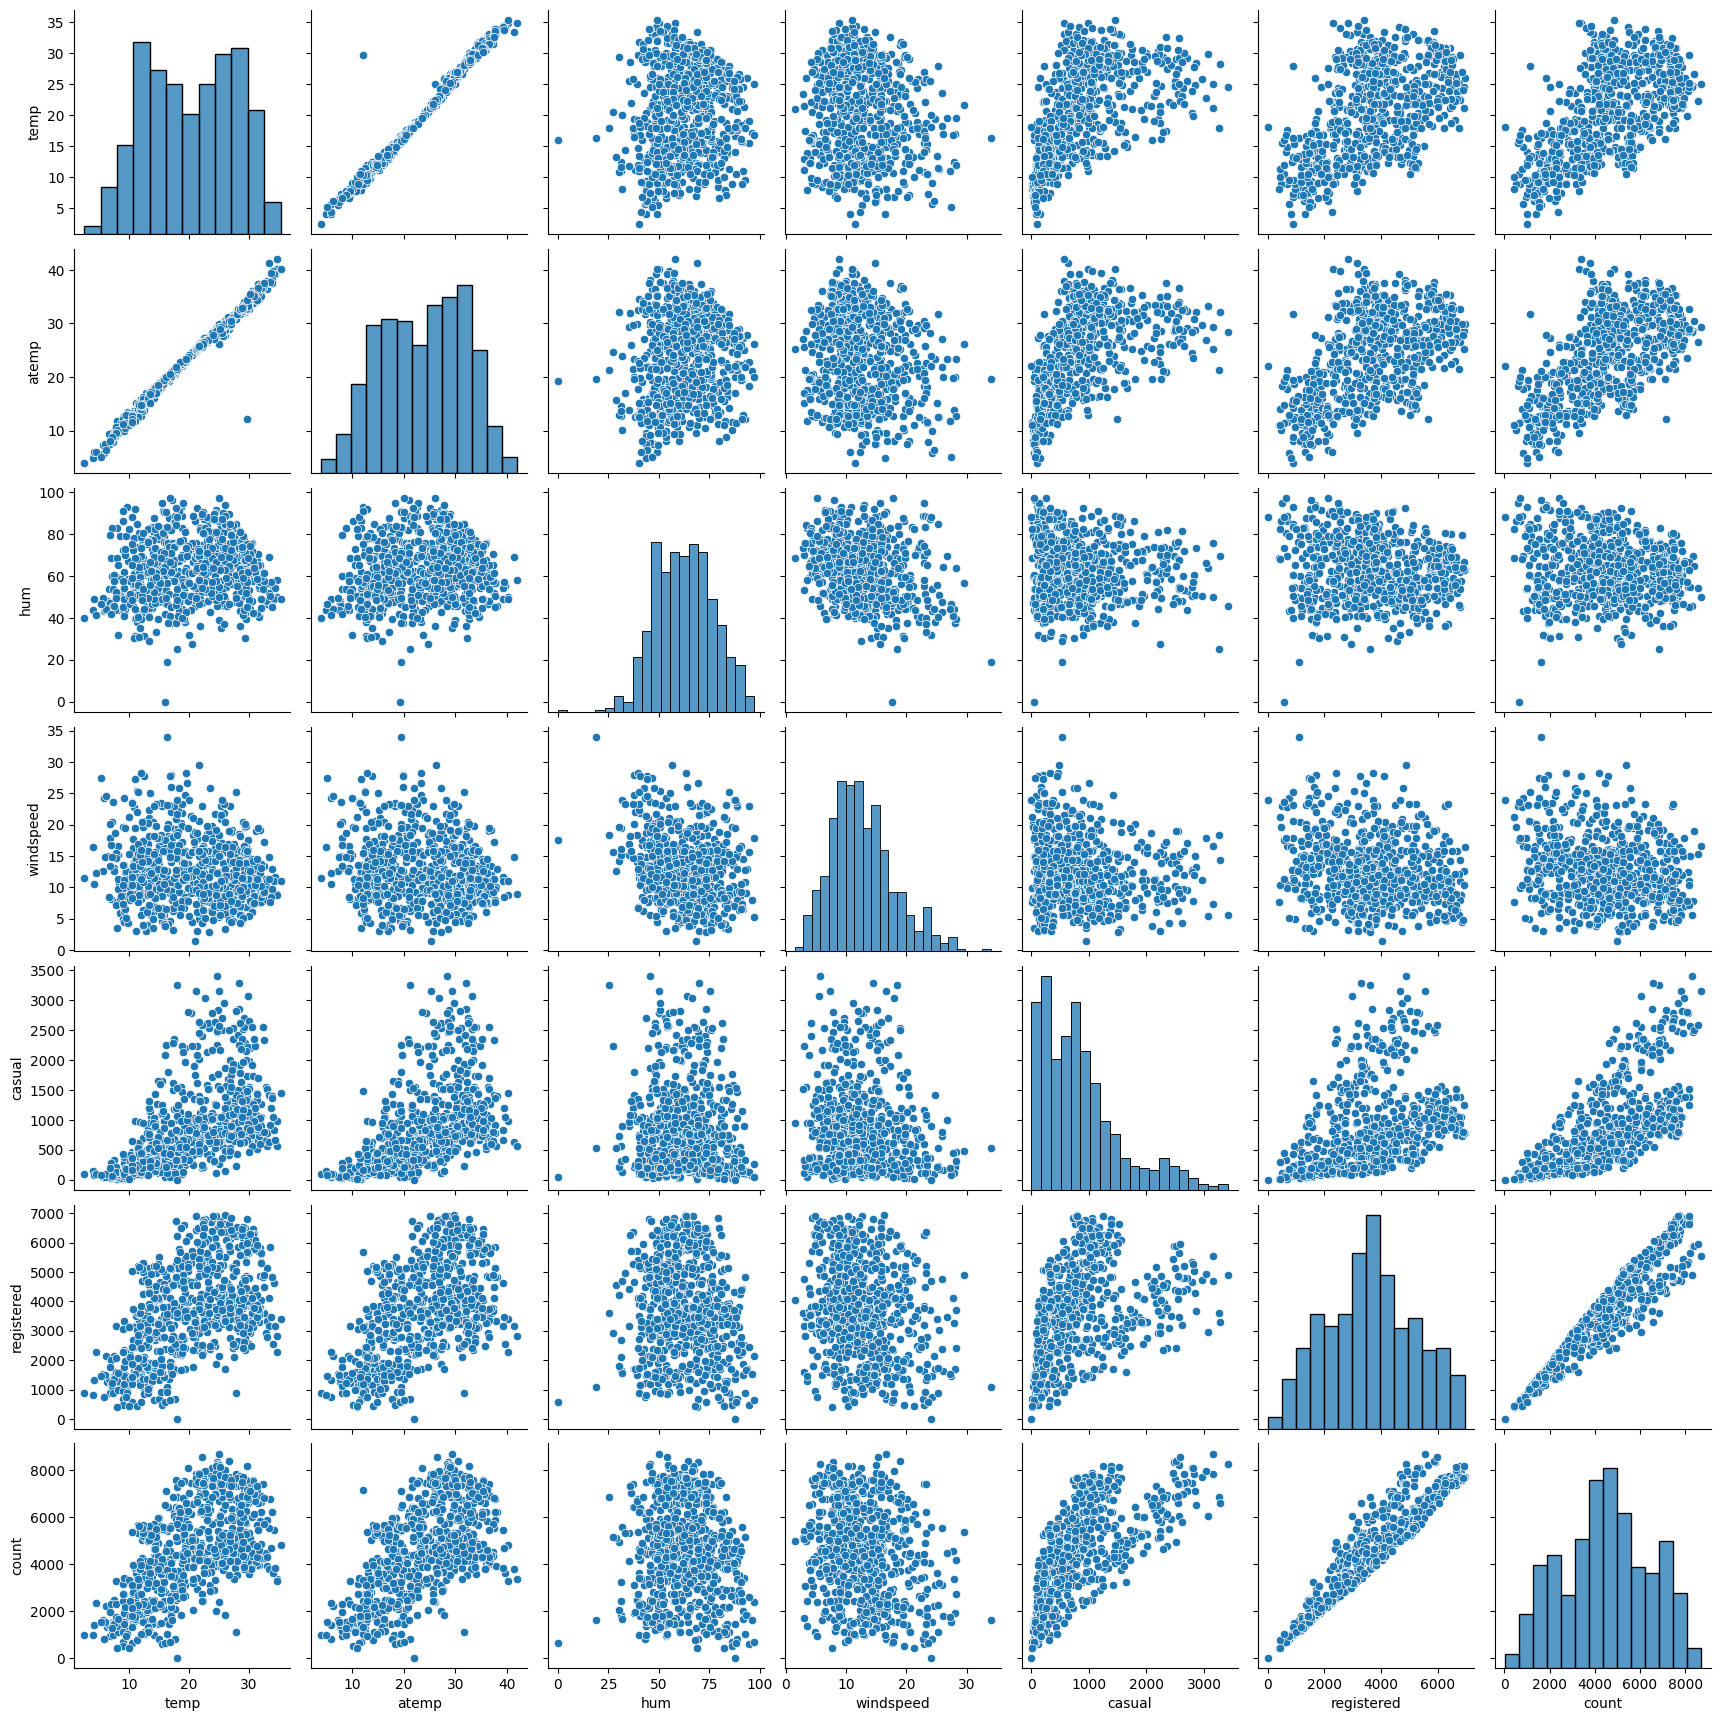

In [ ]:
intVarlist = ["casual", "registered", "count"]

for var in intVarlist:
    df[var] = df[var].astype("float")

dataset_numeric = df.select_dtypes(include=['float64'])
dataset_numeric.head()

sns.pairplot(dataset_numeric)
plt.show()
#Show me every possible relationship between my columns, all at once, visually corelation with each other
#if this feature goes up what happens to other feature that is shown in pairplot

<Axes: >

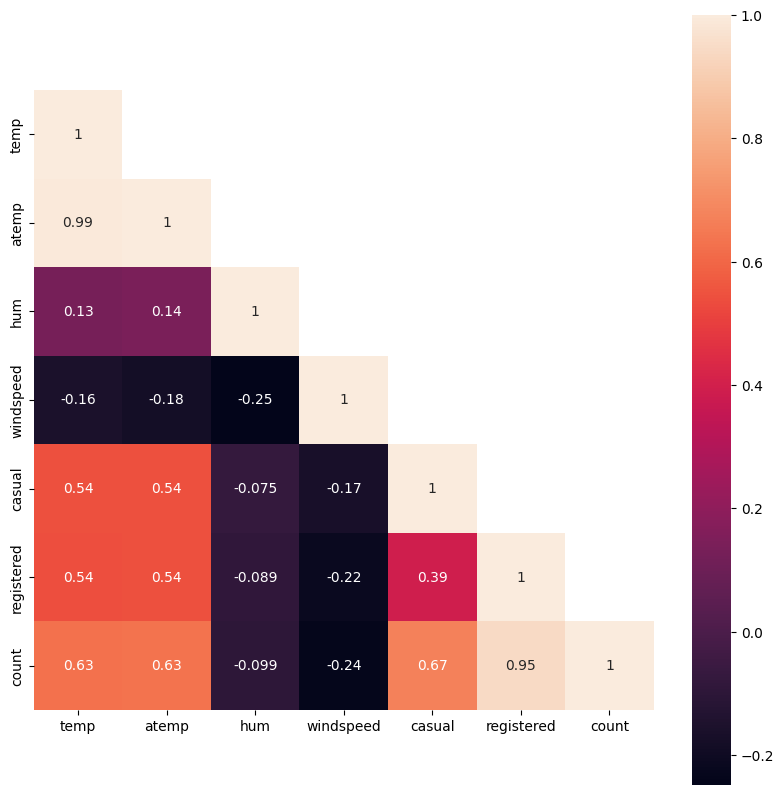

In [ ]:
cor = dataset_numeric.corr()
cor

# heatmap
mask = np.array(cor)
mask[np.tril_indices_from(mask)] = False
fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
sns.heatmap(cor, mask=mask, vmax=1, square=True, annot=True)
#summary of pairplot 

In [ ]:
df.drop('atemp', axis=1, inplace=True)

In [ ]:
df.head()

,SrNo,date,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,count
0,1,2018-01-01,spring,0,Jan,0,Sat,0,Mist,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,spring,0,Jan,0,Sun,0,Mist,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,spring,0,Jan,0,Mon,1,Clear,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,spring,0,Jan,0,Tue,1,Clear,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,spring,0,Jan,0,Wed,1,Clear,9.305237,43.6957,12.522300,82.0,1518.0,1600.0


In [ ]:
dc.head()

,season,mnth,weekday,weathersit
0,spring,Jan,Sat,Mist
1,spring,Jan,Sun,Mist
2,spring,Jan,Mon,Clear
3,spring,Jan,Tue,Clear
4,spring,Jan,Wed,Clear


In [ ]:
df_dummies=pd.get_dummies(dc,drop_first=True,dtype=int
)#gives independent w value for subfeature of feature (wx+b) drop_first to remove first column of dummies to avoid
df_dummies

,season_spring,season_summer,season_winter,mnth_Aug,mnth_Dec,mnth_Feb,mnth_Jan,mnth_Jul,mnth_Jun,mnth_Mar,...,mnth_Oct,mnth_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thur,weekday_Tue,weekday_Wed,weathersit_Light_Rain,weathersit_Mist
0,1,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
726,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
727,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
728,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
df.drop(list(dc.columns),axis=1,inplace=True)
df

,SrNo,date,yr,holiday,workingday,temp,hum,windspeed,casual,registered,count
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,1,0,1,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,2019-12-28,1,0,1,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,2019-12-29,1,0,0,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,2019-12-30,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


In [ ]:
#concat with dummy dataset 
df=pd.concat([df,df_dummies],axis=1)

In [ ]:
df.drop(['SrNo','date'], axis=1, inplace=True,errors='ignore')#axis=0-drop ROWS axis=1-drop COLUMNS
#inplace=true makes changes direcly to original whereas false does it in copy


In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split

y = df['count']                   
X = df.drop('count', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)#it returns numpy we gotta convert it to dataframe(panda)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_test_sc = scaler.transform(X_test)  
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

<Axes: >

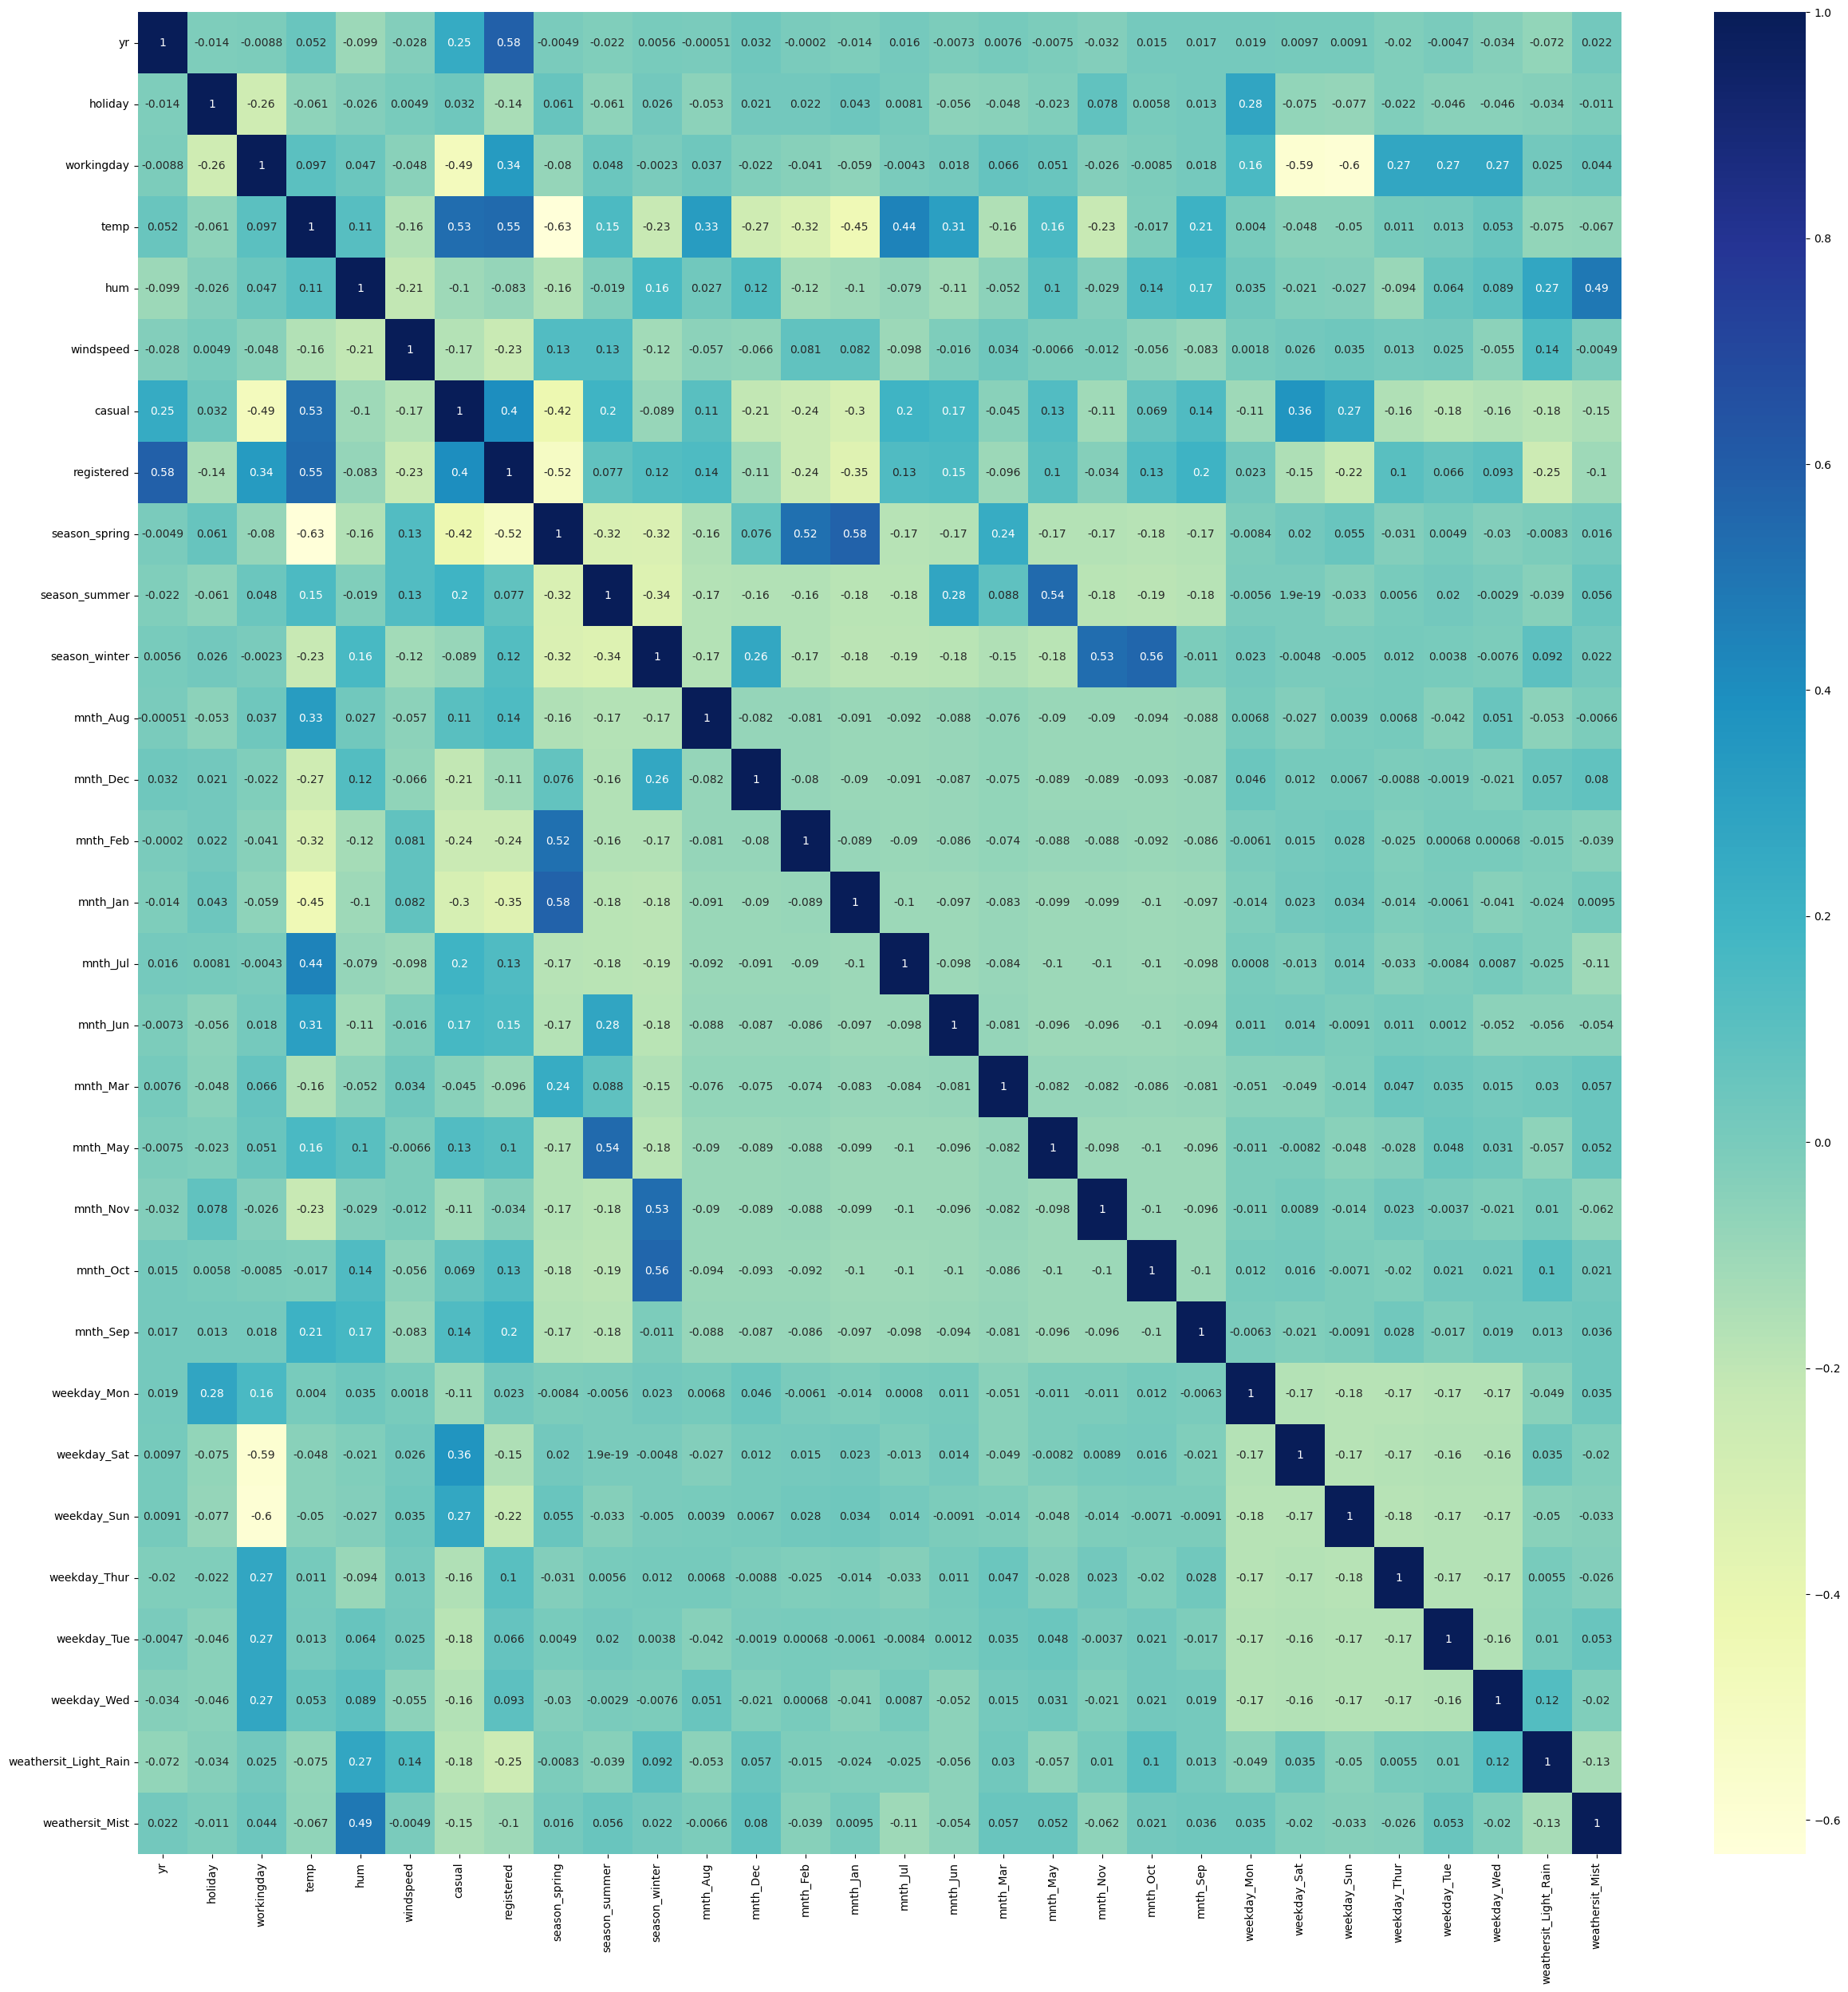

In [ ]:
plt.figure(figsize=(30,30))
sns.heatmap(X_train_sc.corr(), annot=True, cmap="YlGnBu")

In [ ]:
X_train_sc = X_train_sc.drop(['casual','registered'], axis=1)
X_test_sc = X_test_sc.drop(['casual', 'registered'], axis=1)

 #data leakage casual+registered=1 so its same
#axis-1

In [ ]:
#stats model

In [ ]:
import statsmodels.api as sm #stats model is python library used for statistic analysis its 
#sklearn-predicts whereas statsmodel researches,analyzes
X_train_sm=sm.add_constant(X_train_sc)
X_test_sm = sm.add_constant(X_test_sc)
#adds a constant value of 1"s which is there in sklearn b*1
#or else for every point has to start from origin (b decides where it will slope starts from)

In [ ]:
y_train = y_train.reset_index(drop=True)#y indexing is not aligned
lr=sm.OLS(y_train,X_train_sm).fit()#this is just for us to see the summary of stats model not used to build model

In [ ]:
lr.params
lr.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     110.9
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          4.62e-204
Time:                        18:26:28   Log-Likelihood:                -4712.4
No. Observations:                 584   AIC:                             9481.
Df Residuals:                     556   BIC:                             9603.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  4546.3613     32.781    138.690      0.000    4481.972    4610.751
yr                      985.4590     33.611     29.319      0.000     919.439    1051.480
holiday                 -79.0466     33.530     -2.357      0.019    -144.907     -13.186
workingday               66.5734     26.524      2.510      0.012      14.474     118.673
temp                    859.2359     87.066      9.869      0.000     688.217    1030.255
hum                    -206.6569     47.374     -4.362      0.000    -299.712    -113.602
windspeed              -217.3032     36.207     -6.002      0.000    -288.423    -146.183
season_spring          -420.3848    107.896     -3.896      0.000    -632.319    -208.451
season_summer            45.5968     91.043      0.501      0.617    -133.234     224.428
season_winter           332.9557     98.791      3.370      0.001     138.906     527.005
mnth_Aug                -31.7701     74.076     -0.429      0.668    -177.274     113.734
mnth_Dec               -116.1177     77.147     -1.505      0.133    -267.654      35.418
mnth_Feb                -16.1083     76.503     -0.211      0.833    -166.379     134.163
mnth_Jan                -50.4649     85.284     -0.592      0.554    -217.983     117.053
mnth_Jul               -122.2758     81.492     -1.500      0.134    -282.346      37.794
mnth_Jun                 -8.5247     56.319     -0.151      0.880    -119.150     102.100
mnth_Mar                 85.7803     55.631      1.542      0.124     -23.492     195.052
mnth_May                 69.2182     48.748      1.420      0.156     -26.534     164.971
mnth_Nov               -159.7019     88.380     -1.807      0.071    -333.302      13.898
mnth_Oct                 41.3108     88.632      0.466      0.641    -132.783     215.405
mnth_Sep                152.1868     72.842      2.089      0.037       9.107     295.266
weekday_Mon             -74.1581     45.087     -1.645      0.101    -162.719      14.403
weekday_Sat              57.9622     29.208      1.984      0.048       0.591     115.333
weekday_Sun            -104.9595     29.110     -3.606      0.000    -162.139     -47.780
weekday_Thur            -29.0108     44.247     -0.656      0.512    -115.922      57.901
weekday_Tue             -48.3836     43.811     -1.104      0.270    -134.439      37.672
weekday_Wed              -4.0111     44.084     -0.091      0.928     -90.603      82.581
weathersit_Light_Rain  -377.1405     38.390     -9.824      0.000    -452.548    -301.733
weathersit_Mist        -211.0877     41.830     -5.046      0.000    -293.253    -128.923
==============================================================================
Omnibus:                       94.720   Durbin-Watson:                   2.022
Prob(Omnibus):                  0.000   Jarqu

In [ ]:
#with lrsummary we see p values of each feature now instead of removing manually we use RFE(recursive feature eliminator)(eliminating least significantly)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

lm=LinearRegression()
rfe1 = RFE(estimator=lm, n_features_to_select=15)
#fiting with only 15 features
rfe1.fit(X_train_sc,y_train)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",15
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print(rfe1.support_)

[ True  True False  True  True  True  True  True  True False  True False
 False  True False False False  True False  True False False  True False
 False False  True  True]


In [ ]:
col1 = X_train_sc.columns[rfe1.support_]  #eliminates false features

In [ ]:
X_train_rfe1 = X_train_sm[col1]           
X_test_rfe1 = X_test_sm[col1]            



In [ ]:
lm = LinearRegression()
lm.fit(X_train_rfe1, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
from sklearn.metrics import r2_score

y_pred = lm.predict(X_test_rfe1)
r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)

R2 Score: 0.8607550201194892


In [ ]:
 #VIF removes duplicate features hen two or more features are highly correlated with each other 
 # This is a problem because the model gets confusedcan't tell which feature is actually causing the target to change.
from statsmodels.stats.outliers_influence import variance_inflation_factor
a = X_train_rfe1.copy()
vif = pd.DataFrame()
vif["Features"] = a.columns
vif['VIF'] = [variance_inflation_factor(a.values, i) for i in range(a.shape[1])]
#what exactly is happening is for each feature eg temp VIF predict temp using other features(i=1 first feature)
#how vif is calculated is by taking each feature acalculating R2 score of that regression and then 
#if R2 is high then VIF will be high which means that feature is highly correlated 
#if R2 is low then VIF will be low which means that feature is not highly correlated 

In [ ]:
vif['VIF'] = vif['VIF'].round(3)  #rounding up
vif.sort_values(by='VIF', ascending=False)

,Features,VIF
5,season_spring,5.397
2,temp,4.122
7,season_winter,3.646
6,season_summer,2.756
3,hum,1.932
10,mnth_Nov,1.736
9,mnth_Jul,1.655
14,weathersit_Mist,1.591
11,mnth_Sep,1.384
13,weathersit_Light_Rain,1.330


In [ ]:
lm=LinearRegression()
rfe2 = RFE(estimator=lm, n_features_to_select=10)
col2=X_train_rfe1.columns[rfe2.fit(X_train_rfe1, y_train).support_]
col2

Index(['yr', 'temp', 'hum', 'windspeed', 'season_spring', 'season_summer',
       'season_winter', 'mnth_Sep', 'weathersit_Light_Rain',
       'weathersit_Mist'],
      dtype='object')

In [ ]:
X_train_rfe2 = X_train_rfe1[col2]
X_test_rfe2 = X_test_rfe1[col2]
X_train_rfe2=sm.add_constant(X_train_rfe2)
X_test_rfe2=sm.add_constant(X_test_rfe2)
lm2 = sm.OLS(y_train, X_train_rfe2).fit()
lm2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     264.4
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          2.82e-207
Time:                        18:33:46   Log-Likelihood:                -4750.0
No. Observations:                 584   AIC:                             9522.
Df Residuals:                     573   BIC:                             9570.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  4546.3613     34.440    132.009      0.000    4478.717    4614.005
yr                      984.7564     34.994     28.141      0.000     916.025    1053.488
temp                    970.5027     64.793     14.978      0.000     843.242    1097.764
hum                    -213.9877     47.417     -4.513      0.000    -307.120    -120.856
windspeed              -228.1653     37.362     -6.107      0.000    -301.549    -154.782
season_spring          -259.2851     75.549     -3.432      0.001    -407.671    -110.899
season_summer           247.2270     50.796      4.867      0.000     147.457     346.997
season_winter           393.5032     61.312      6.418      0.000     273.080     513.926
mnth_Sep                221.1658     37.558      5.889      0.000     147.397     294.934
weathersit_Light_Rain  -344.1129     39.443     -8.724      0.000    -421.583    -266.643
weathersit_Mist        -187.7863     43.277     -4.339      0.000    -272.788    -102.785
==============================================================================
Omnibus:                       80.475   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              175.928
Skew:                          -0.760   Prob(JB):                     6.28e-39
Kurtosis:                       5.217   Cond. No.                         4.64
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# X_test_rfe2.info()

In [ ]:
y_pred = lm2.predict(X_test_rfe2)
r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)

R2 Score: 0.8534333816301822
